In [1]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120)

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
MODELS_DIR = PROJECT_ROOT / 'models'
for directory in (DATA_DIR, OUTPUTS_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

from model import set_seeds
set_seeds(42)

print('torch', torch.__version__, '| pandas', pd.__version__)

torch 2.3.1+cpu | pandas 2.2.2


In [2]:
from preprocess import load_raw

supplied = load_raw(str(DATA_DIR / 'ecommerce_inventory_demand.csv'))
gaps = supplied.groupby('product_id')['date'].diff().dt.days.dropna()

print('Supplied dataset')
print(f'  rows                 : {len(supplied):,}')
print(f'  SKUs                 : {supplied.product_id.nunique()}')
print(f'  date span            : {supplied.date.min().date()} to {supplied.date.max().date()}')
print(f'  median gap between   : {gaps.median():.0f} days')
print(f'  max gap between rows : {gaps.max():.0f} days')
print(f'  coverage             : {len(supplied) / (supplied.product_id.nunique() * 730):.1%} of SKU-days')

Supplied dataset
  rows                 : 6,223
  SKUs                 : 50
  date span            : 2022-01-01 to 2023-12-31
  median gap between   : 4 days
  max gap between rows : 44 days
  coverage             : 17.0% of SKU-days


In [3]:
import data_generator

data_generator.set_seeds(42)
daily = data_generator.generate_dataset(n_products=50, noise=0.10, missing_rate=0.02)
DATA_PATH = DATA_DIR / 'synthetic_inventory_demand.csv'
daily.to_csv(DATA_PATH, index=False)

print(f'Generated {len(daily):,} rows for {daily.product_id.nunique()} SKUs '
      f'({len(daily) / (daily.product_id.nunique() * 730):.0%} SKU-day coverage)')
daily.head()

Generated 36,500 rows for 50 SKUs (100% SKU-day coverage)


,date,product_id,product_category,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,day_of_week,month,supplier_lead_days
0,2022-01-01,P001,Electronics,57.0,57190.72,1197,20,0,0.0,5,1,3
1,2022-01-02,P001,Electronics,49.0,57190.72,1175,20,0,0.0,6,1,3
2,2022-01-03,P001,Electronics,35.0,57190.72,1173,20,0,0.0,0,1,3
3,2022-01-04,P001,Electronics,44.0,57190.72,1141,20,0,0.0,1,1,3
4,2022-01-05,P001,Electronics,41.0,57190.72,1101,20,0,0.0,2,1,3


In [4]:
df = load_raw(str(DATA_PATH))

print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or '  (none outside units_sold)')
print()
print(df[['units_sold', 'unit_price', 'stock_on_hand', 'discount_pct']].describe().round(2))

Missing values per column:
units_sold    754

       units_sold  unit_price  stock_on_hand  discount_pct
count    35746.00    36500.00       36500.00      36500.00
mean        42.51    12981.11          44.69          1.09
std         21.94    16236.28         172.66          5.12
min          7.00      181.97           0.00          0.00
25%         25.00     2568.13           0.00          0.00
50%         40.00     5461.31           0.00          0.00
75%         56.00    11615.00           0.00          0.00
max        213.00    57190.72        1494.00         40.00


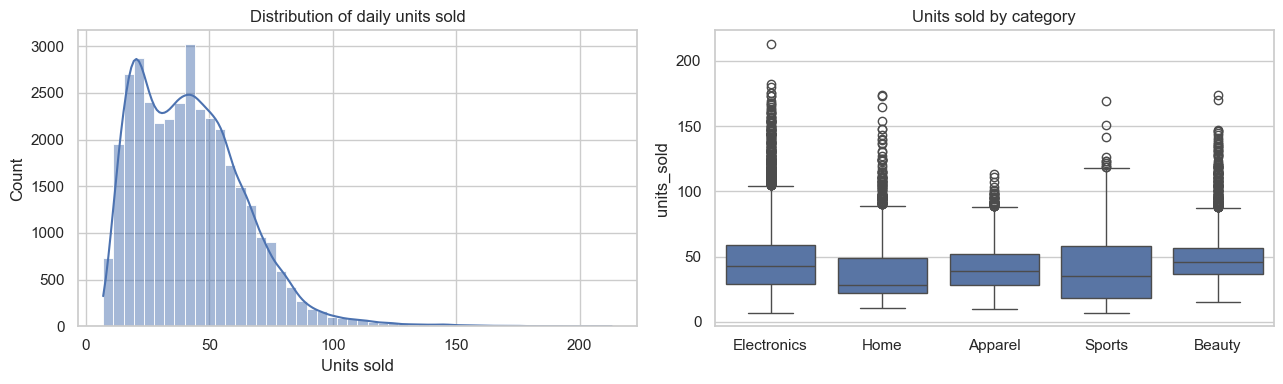

Right-skewed, as demand data usually is: a long tail of promotion and festival days sits above a dense weekday body.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['units_sold'].dropna(), bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of daily units sold')
axes[0].set_xlabel('Units sold')

sns.boxplot(data=df, x='product_category', y='units_sold', ax=axes[1])
axes[1].set_title('Units sold by category')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_units_sold_distribution.png', dpi=130)
plt.show()

print('Right-skewed, as demand data usually is: a long tail of promotion and '
      'festival days sits above a dense weekday body.')

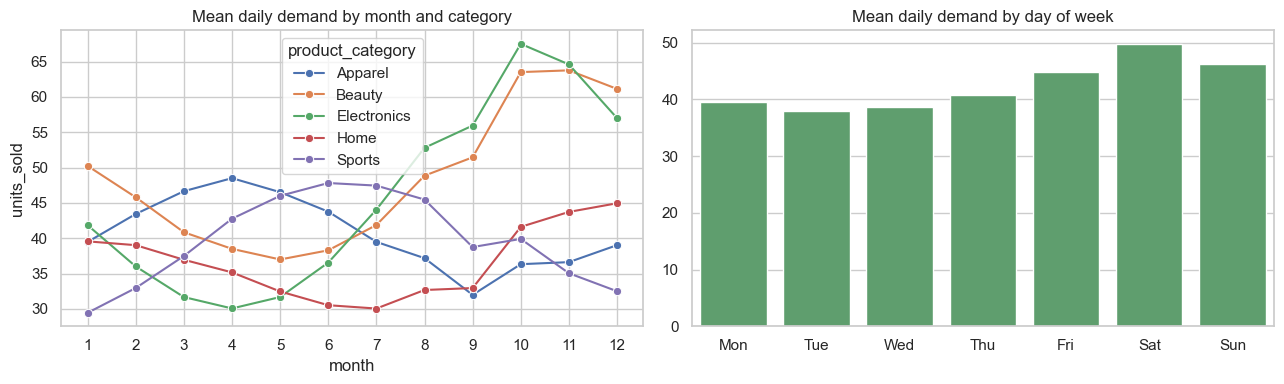

Weekend uplift: 18.9% above weekdays.
Categories peak in different months, which is why product_category is one-hot encoded rather than dropped.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

monthly = df.groupby(['product_category', 'month'])['units_sold'].mean().reset_index()
sns.lineplot(data=monthly, x='month', y='units_sold', hue='product_category',
             marker='o', ax=axes[0])
axes[0].set_title('Mean daily demand by month and category')
axes[0].set_xticks(range(1, 13))

dow = df.groupby('day_of_week')['units_sold'].mean()
sns.barplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            y=dow.values, ax=axes[1], color='#55A868')
axes[1].set_title('Mean daily demand by day of week')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_seasonality.png', dpi=130)
plt.show()

print(f'Weekend uplift: {(dow[5:].mean() / dow[:5].mean() - 1):.1%} above weekdays.')
print('Categories peak in different months, which is why product_category is '
      'one-hot encoded rather than dropped.')

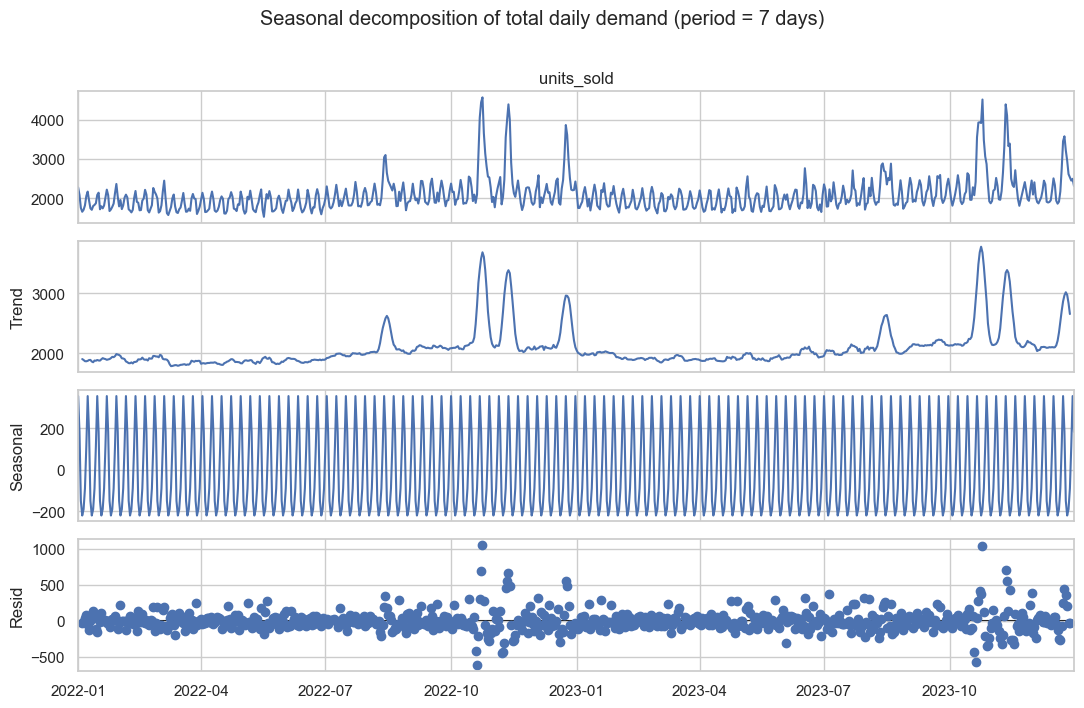

Weekly seasonal strength: 0.652 (0 = no weekly signal, 1 = purely seasonal)


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

total_daily = (df.groupby('date')['units_sold'].sum()
                 .asfreq('D').interpolate())
decomposition = seasonal_decompose(total_daily, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(11, 7)
fig.suptitle('Seasonal decomposition of total daily demand (period = 7 days)', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_decomposition.png', dpi=130)
plt.show()

seasonal_strength = 1 - decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var()
print(f'Weekly seasonal strength: {seasonal_strength:.3f} '
      f'(0 = no weekly signal, 1 = purely seasonal)')

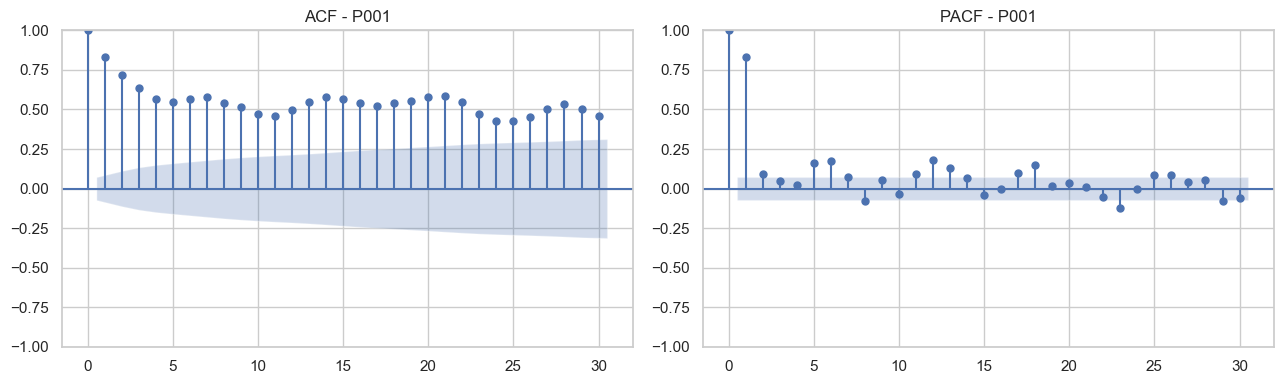

  autocorrelation at lag  1:  0.831
  autocorrelation at lag  7:  0.582
  autocorrelation at lag 14:  0.594
  autocorrelation at lag 30:  0.473

Lag-1 is the strongest single predictor, with a secondary bump around lag-7 from the weekly cycle. This is the evidence behind the feature set in section 4 - and behind adding prev_demand (lag-1), which the original pipeline omitted.


In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sku = df['product_id'].value_counts().idxmax()
series = (df[df.product_id == sku].sort_values('date')
            .set_index('date')['units_sold'].asfreq('D').interpolate())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series, lags=30, ax=axes[0], title=f'ACF - {sku}')
plot_pacf(series, lags=30, ax=axes[1], method='ywm', title=f'PACF - {sku}')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / f'eda_acf_{sku}.png', dpi=130)
plt.show()

acf_values = [series.autocorr(lag) for lag in (1, 7, 14, 30)]
for lag, value in zip((1, 7, 14, 30), acf_values):
    print(f'  autocorrelation at lag {lag:>2}: {value: .3f}')
print()
print('Lag-1 is the strongest single predictor, with a secondary bump around '
      'lag-7 from the weekly cycle. This is the evidence behind the feature set '
      'in section 4 - and behind adding prev_demand (lag-1), which the original '
      'pipeline omitted.')

In [10]:
def iqr_outlier_count(group):
    q1, q3 = group.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((group < q1 - 1.5 * iqr) | (group > q3 + 1.5 * iqr)).sum()

outlier_summary = pd.DataFrame({
    'price_outliers': df.groupby('product_category')['unit_price'].apply(iqr_outlier_count),
    'demand_outliers': df.groupby('product_category')['units_sold'].apply(iqr_outlier_count),
    'rows': df.groupby('product_category').size(),
})
outlier_summary['price_outlier_pct'] = (outlier_summary.price_outliers
                                        / outlier_summary.rows * 100).round(2)
print(outlier_summary)
print()
print('Demand outliers are kept: they are real promotion and festival spikes, '
      'which the model is supposed to learn. Only unit_price is clipped.')

                  price_outliers  demand_outliers   rows  price_outlier_pct
product_category                                                           
Apparel                        0               43   7300                0.0
Beauty                         0              160   5110                0.0
Electronics                    0              257  10950                0.0
Home                           0              100   5840                0.0
Sports                         0               10   7300                0.0

Demand outliers are kept: they are real promotion and festival spikes, which the model is supposed to learn. Only unit_price is clipped.


In [11]:
from preprocess import (reindex_daily, handle_missing_values,
                        remove_price_outliers, add_calendar_features)

step1 = reindex_daily(df)
step2 = handle_missing_values(step1)
step3 = remove_price_outliers(step2)
step4 = add_calendar_features(step3)

print(f'raw                  : {len(df):,} rows, {df.units_sold.isna().sum():,} missing targets')
print(f'after daily reindex  : {len(step1):,} rows')
print(f'after forward fill   : {len(step2):,} rows, {step2.units_sold.isna().sum():,} missing targets')
print(f'after IQR clipping   : unit_price max {step2.unit_price.max():,.0f} -> {step3.unit_price.max():,.0f}')
print(f'after calendar feats : {step4.shape[1]} columns')
step4[['date', 'product_id', 'units_sold', 'is_weekend', 'dow_sin', 'month_sin']].head()

raw                  : 36,500 rows, 754 missing targets
after daily reindex  : 36,500 rows
after forward fill   : 36,500 rows, 0 missing targets
after IQR clipping   : unit_price max 57,191 -> 57,191
after calendar feats : 21 columns


,date,product_id,units_sold,is_weekend,dow_sin,month_sin
0,2022-01-01,P001,57.0,1,-0.974928,0.5
1,2022-01-02,P001,49.0,1,-0.781831,0.5
2,2022-01-03,P001,35.0,0,0.000000,0.5
3,2022-01-04,P001,44.0,0,0.781831,0.5
4,2022-01-05,P001,41.0,0,0.974928,0.5


In [12]:
from preprocess import add_lag_and_rolling_features, encode_categoricals, NUMERIC_FEATURES

featured = add_lag_and_rolling_features(step4)
featured = encode_categoricals(featured)
featured = featured.dropna(subset=['roll_mean_30', 'roll_std_30', 'lag_14',
                                   'prev_demand']).reset_index(drop=True)

print(f'Rows after dropping the 30-day warm-up window: {len(featured):,}')
featured[['date', 'product_id', 'units_sold', 'prev_demand', 'lag_7', 'lag_14',
          'roll_mean_7', 'roll_std_30']].head(8).round(2)

Rows after dropping the 30-day warm-up window: 35,000


,date,product_id,units_sold,prev_demand,lag_7,lag_14,roll_mean_7,roll_std_30
0,2022-01-31,P001,44.0,46.0,38.0,47.0,47.57,7.78
1,2022-02-01,P001,39.0,44.0,39.0,46.0,48.43,7.68
2,2022-02-02,P001,36.0,39.0,47.0,46.0,48.43,7.88
3,2022-02-03,P001,41.0,36.0,47.0,42.0,46.86,7.82
4,2022-02-04,P001,41.0,41.0,50.0,60.0,46.00,7.90
5,2022-02-05,P001,47.0,41.0,66.0,49.0,44.71,7.90
6,2022-02-06,P001,46.0,47.0,46.0,60.0,42.00,7.89
7,2022-02-07,P001,40.0,46.0,44.0,38.0,42.00,7.82


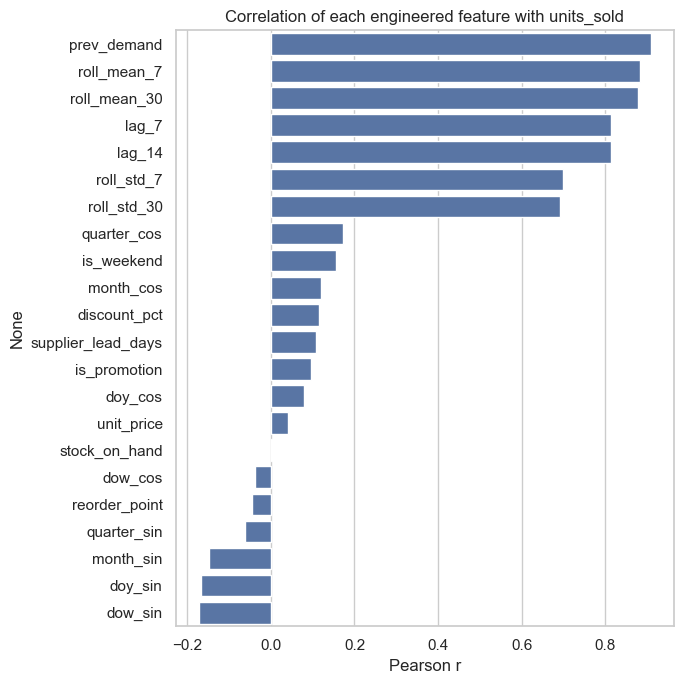

In [13]:
correlations = (featured[NUMERIC_FEATURES + ['units_sold']]
                .corr()['units_sold'].drop('units_sold')
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 7))
sns.barplot(x=correlations.values, y=correlations.index, ax=ax, color='#4C72B0')
ax.set_title('Correlation of each engineered feature with units_sold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_feature_correlation.png', dpi=130)
plt.show()

In [14]:
from preprocess import run_pipeline

pipeline = run_pipeline(str(DATA_PATH))
train_df, val_df, test_df = pipeline['train_df'], pipeline['val_df'], pipeline['test_df']
feature_columns = pipeline['feature_columns']
scaler = pipeline['scaler']

split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame),
     'from': frame.date.min().date(), 'to': frame.date.max().date()}
    for name, frame in [('train', train_df), ('validation', val_df), ('test', test_df)]
])
print(split_summary.to_string(index=False))
print(f'\nFeatures fed to the models: {len(feature_columns)}')
print(f'Scaler fitted on train only: min of scaled train = '
      f'{train_df[feature_columns[:12]].min().min():.3f}, '
      f'max = {train_df[feature_columns[:12]].max().max():.3f}')
print(f'Test set scaled with the SAME scaler, so it is allowed to fall outside '
      f'[0, 1]: min = {test_df[feature_columns[:12]].min().min():.3f}, '
      f'max = {test_df[feature_columns[:12]].max().max():.3f}')

     split  rows       from         to
     train 24500 2022-01-31 2023-06-04
validation  3500 2023-06-05 2023-08-13
      test  7000 2023-08-14 2023-12-31

Features fed to the models: 27
Scaler fitted on train only: min of scaled train = 0.000, max = 1.000
Test set scaled with the SAME scaler, so it is allowed to fall outside [0, 1]: min = 0.000, max = 1.226


In [15]:
import pickle

with open(MODELS_DIR / 'scaler.pkl', 'wb') as handle:
    pickle.dump(scaler, handle)
with open(MODELS_DIR / 'feature_columns.json', 'w') as handle:
    json.dump(feature_columns, handle, indent=2)
print('Saved scaler.pkl and feature_columns.json')

Saved scaler.pkl and feature_columns.json


In [16]:
from model import DemandLSTM, DemandMLP, SlidingWindowDataset, TabularDataset
from preprocess import bridge_for_windows

SEQUENCE_LENGTH = 14
BATCH_SIZE = 256
set_seeds(42)

val_bridged = bridge_for_windows(train_df, val_df, SEQUENCE_LENGTH)
test_bridged = bridge_for_windows(pd.concat([train_df, val_df], ignore_index=True),
                                  test_df, SEQUENCE_LENGTH)

train_seq = SlidingWindowDataset(train_df, feature_columns, sequence_length=SEQUENCE_LENGTH)
val_seq = SlidingWindowDataset(val_bridged, feature_columns, sequence_length=SEQUENCE_LENGTH)
test_seq = SlidingWindowDataset(test_bridged, feature_columns, sequence_length=SEQUENCE_LENGTH)

train_tab = TabularDataset(train_df, feature_columns)
val_tab = TabularDataset(val_df, feature_columns)
test_tab = TabularDataset(test_df, feature_columns)

print(f'LSTM windows : train {len(train_seq):,} | val {len(val_seq):,} | test {len(test_seq):,}')
print(f'MLP rows     : train {len(train_tab):,} | val {len(val_tab):,} | test {len(test_tab):,}')
print(f'Window shape : {train_seq[0][0].shape}  (sequence_length x n_features)')
print(f'\nBridging recovered {len(test_seq) - (len(test_df) - 50 * SEQUENCE_LENGTH):,} '
      f'test windows that would otherwise have been dropped.')

LSTM windows : train 23,800 | val 3,500 | test 7,000
MLP rows     : train 24,500 | val 3,500 | test 7,000
Window shape : torch.Size([14, 27])  (sequence_length x n_features)

Bridging recovered 700 test windows that would otherwise have been dropped.


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = DemandLSTM(input_size=len(feature_columns))
mlp_model = DemandMLP(input_size=len(feature_columns))

def count_parameters(model):
    """Count trainable parameters in a model.

    Args:
        model: A PyTorch module.

    Returns:
        The number of trainable parameters as an int.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(lstm_model)
print(f'\nLSTM trainable parameters : {count_parameters(lstm_model):,}')
print(f'MLP  trainable parameters : {count_parameters(mlp_model):,}')
print(f'Device                    : {device}')

DemandLSTM(
  (lstm): LSTM(27, 96, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=96, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

LSTM trainable parameters : 125,633
MLP  trainable parameters : 13,953
Device                    : cpu


In [18]:
from torch.utils.tensorboard import SummaryWriter
from train import train_one_model

writer = SummaryWriter(log_dir=str(PROJECT_ROOT / 'runs' / 'neuralstock'))
set_seeds(42)

lstm_model, lstm_history = train_one_model(
    lstm_model,
    DataLoader(train_seq, batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(val_seq, batch_size=BATCH_SIZE, shuffle=False),
    epochs=60, lr=1e-3, writer=writer, tag='LSTM', device=device)

[LSTM] epoch   1/60  train_mse= 82.6925  val_mse= 49.4437
[LSTM] epoch   5/60  train_mse= 48.4947  val_mse= 44.4208
[LSTM] epoch  10/60  train_mse= 43.1073  val_mse= 42.4636
[LSTM] epoch  15/60  train_mse= 39.4310  val_mse= 41.7365
[LSTM] epoch  20/60  train_mse= 37.6656  val_mse= 41.8539
[LSTM] epoch  25/60  train_mse= 34.9335  val_mse= 42.9041
[LSTM] epoch  30/60  train_mse= 34.3032  val_mse= 41.1228
[LSTM] epoch  35/60  train_mse= 33.1638  val_mse= 43.6758
[LSTM] early stop at epoch 39 (no val improvement for 10 epochs)


[LSTM] epoch  10/60  train_mse= 42.3987  val_mse= 41.9966


[LSTM] epoch  15/60  train_mse= 39.6861  val_mse= 41.2135


[LSTM] epoch  20/60  train_mse= 37.9109  val_mse= 43.8533


[LSTM] epoch  25/60  train_mse= 35.5795  val_mse= 45.6912
[LSTM] early stop at epoch 25 (no val improvement for 10 epochs)


In [19]:
set_seeds(42)
mlp_model, mlp_history = train_one_model(
    mlp_model,
    DataLoader(train_tab, batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(val_tab, batch_size=BATCH_SIZE, shuffle=False),
    epochs=60, lr=1e-3, writer=writer, tag='MLP', device=device)

writer.close()
torch.save(lstm_model.state_dict(), MODELS_DIR / 'lstm_model.pt')
torch.save(mlp_model.state_dict(), MODELS_DIR / 'mlp_model.pt')
print('\nSaved lstm_model.pt and mlp_model.pt')

[MLP] epoch   1/60  train_mse= 80.5791  val_mse= 40.7619
[MLP] epoch   5/60  train_mse= 49.5325  val_mse= 32.7795
[MLP] epoch  10/60  train_mse= 40.9362  val_mse= 33.3541
[MLP] epoch  15/60  train_mse= 38.1694  val_mse= 33.2185
[MLP] early stop at epoch 15 (no val improvement for 10 epochs)

Saved lstm_model.pt and mlp_model.pt


[MLP] epoch  10/60  train_mse= 39.8542  val_mse= 33.2281


[MLP] early stop at epoch 14 (no val improvement for 10 epochs)

Saved lstm_model.pt and mlp_model.pt


In [23]:
from train import predict, score_daily_and_weekly, regression_metrics

lstm_test_pred = predict(lstm_model, DataLoader(test_seq, batch_size=BATCH_SIZE), device)
lstm_train_pred = predict(lstm_model, DataLoader(train_seq, batch_size=BATCH_SIZE), device)
mlp_test_pred = predict(mlp_model, DataLoader(test_tab, batch_size=BATCH_SIZE), device)

naive_test_pred = lstm_test_pred.copy()
naive_test_pred['y_pred'] = naive_test_pred['baseline']

lstm_metrics = score_daily_and_weekly(lstm_test_pred, test_bridged)
lstm_train_metrics = score_daily_and_weekly(lstm_train_pred, train_df)
mlp_metrics = score_daily_and_weekly(mlp_test_pred, test_df)
naive_metrics = score_daily_and_weekly(naive_test_pred, test_bridged)

daily_table = pd.DataFrame({
    'LSTM': lstm_metrics['daily'],
    'MLP': mlp_metrics['daily'],
    'Naive (roll_mean_7)': naive_metrics['daily'],
}).T.round(3)
daily_table.columns = ['MSE', 'RMSE', 'MAE', 'MAPE %', 'R2']
print('Test-set metrics - daily, per SKU')
print(daily_table.to_string())

Test-set metrics - daily, per SKU
                         MSE    RMSE    MAE  MAPE %     R2
LSTM                  86.214   9.285  6.058  12.603  0.878
MLP                  112.344  10.599  7.001  14.163  0.840
Naive (roll_mean_7)  192.628  13.879  9.054  18.301  0.726


In [24]:
weekly_table = pd.DataFrame({
    'LSTM': lstm_metrics['weekly'],
    'MLP': mlp_metrics['weekly'],
    'Naive (roll_mean_7)': naive_metrics['weekly'],
}).T.round(3)
weekly_table.columns = ['MSE', 'RMSE', 'MAE', 'MAPE %', 'R2']
print('Test-set metrics - weekly demand per product category')
print(weekly_table.to_string())

Test-set metrics - weekly demand per product category
                            MSE     RMSE      MAE  MAPE %     R2
LSTM                  56041.977  236.732  167.396   4.774  0.980
MLP                   82815.039  287.776  172.220   4.917  0.971
Naive (roll_mean_7)  181578.766  426.121  270.640   7.632  0.936


In [25]:
from train import targets_table

acceptance = targets_table(lstm_metrics)
print('LSTM against the project acceptance criteria:')
print(acceptance.to_string(index=False))

LSTM against the project acceptance criteria:
       metric  level  target  achieved status
     MAPE (%) weekly   12.00    4.7736   PASS
           R2 weekly    0.85    0.9803   PASS
  MAE (units)  daily   10.00    6.0582   PASS
 RMSE (units)  daily   15.00    9.2852   PASS
MSE (units^2)  daily     NaN   86.2142      -


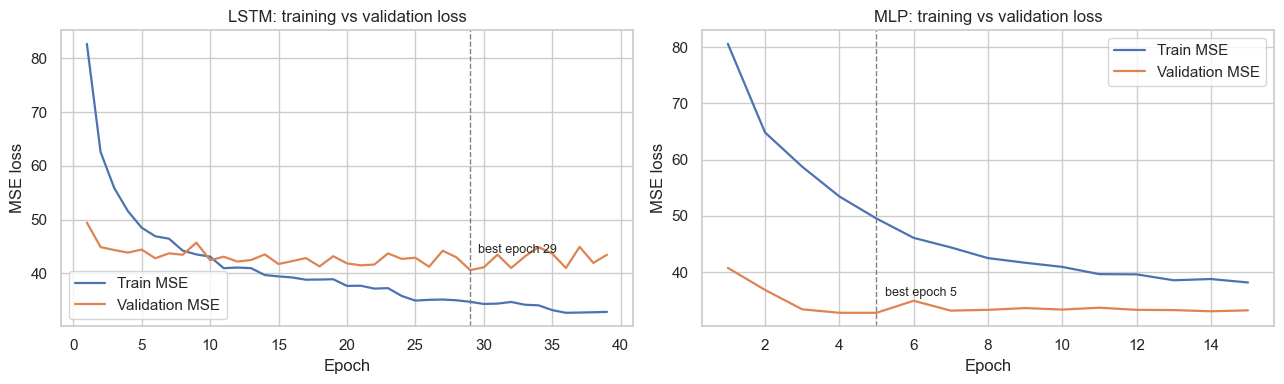

In [26]:
from train import overfitting_report, save_loss_curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, history) in zip(axes, [('LSTM', lstm_history), ('MLP', mlp_history)]):
    ax.plot(history.epoch, history.train_loss, label='Train MSE', linewidth=1.6)
    ax.plot(history.epoch, history.val_loss, label='Validation MSE', linewidth=1.6)
    best = history.loc[history.val_loss.idxmin()]
    ax.axvline(best.epoch, color='grey', linestyle='--', linewidth=1)
    ax.annotate(f'best epoch {int(best.epoch)}', xy=(best.epoch, best.val_loss),
                xytext=(6, 12), textcoords='offset points', fontsize=9)
    ax.set_title(f'{name}: training vs validation loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss'); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'loss_curves.png', dpi=130)
plt.show()

save_loss_curves({'LSTM': lstm_history, 'MLP': mlp_history},
                 str(OUTPUTS_DIR / 'loss_curves.png'))

In [33]:
overfit = overfitting_report(lstm_history, lstm_train_metrics['daily'], lstm_metrics['daily'])
print('Overfitting check - LSTM')
for key, value in overfit.items():
    print(f'  {key:<32} {value if isinstance(value, str) else round(value, 4)}')
print()

Overfitting check - LSTM
  best_epoch                       29
  train_loss_at_best               34.7031
  val_loss_at_best                 40.6021
  val_over_train_loss_ratio        1.17
  train_mape                       10.103
  test_mape                        12.6027
  test_minus_train_mape_points     2.4997
  verdict                          not overfitting



### 6.4 Actual vs predicted

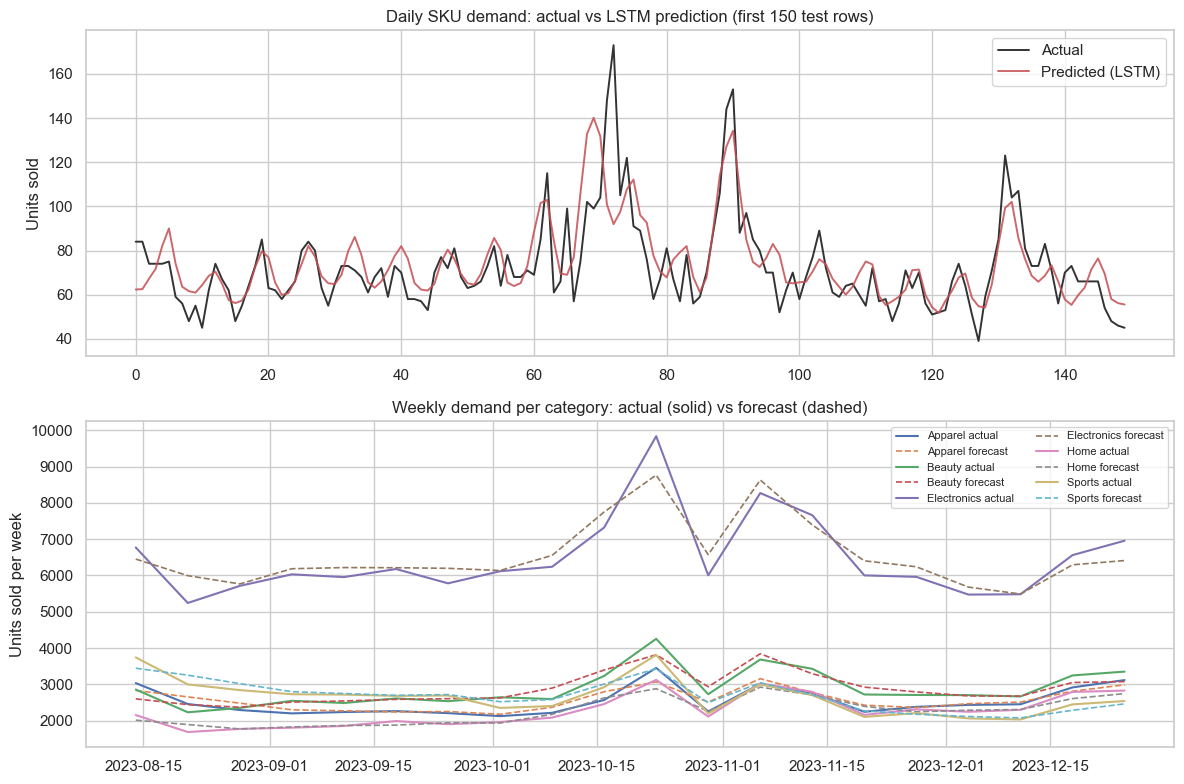

In [28]:
from train import save_actual_vs_predicted_plot

joined = lstm_test_pred.join(test_bridged[['date', 'product_category', 'product_id']],
                             how='inner')
save_actual_vs_predicted_plot(joined, str(OUTPUTS_DIR / 'actual_vs_predicted.png'))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sample = joined.head(150)
axes[0].plot(sample.y_true.values, label='Actual', color='#333333', linewidth=1.4)
axes[0].plot(sample.y_pred.values, label='Predicted (LSTM)', color='#C44E52',
             alpha=0.85, linewidth=1.4)
axes[0].set_title('Daily SKU demand: actual vs LSTM prediction (first 150 test rows)')
axes[0].set_ylabel('Units sold'); axes[0].legend()

from preprocess import aggregate_weekly
weekly = aggregate_weekly(joined).sort_values('week')
for category, group in weekly.groupby('product_category'):
    axes[1].plot(group.week, group.y_true, linewidth=1.5, label=f'{category} actual')
    axes[1].plot(group.week, group.y_pred, linewidth=1.2, linestyle='--',
                 label=f'{category} forecast')
axes[1].set_title('Weekly demand per category: actual (solid) vs forecast (dashed)')
axes[1].set_ylabel('Units sold per week')
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'actual_vs_predicted_weekly.png', dpi=130)
plt.show()

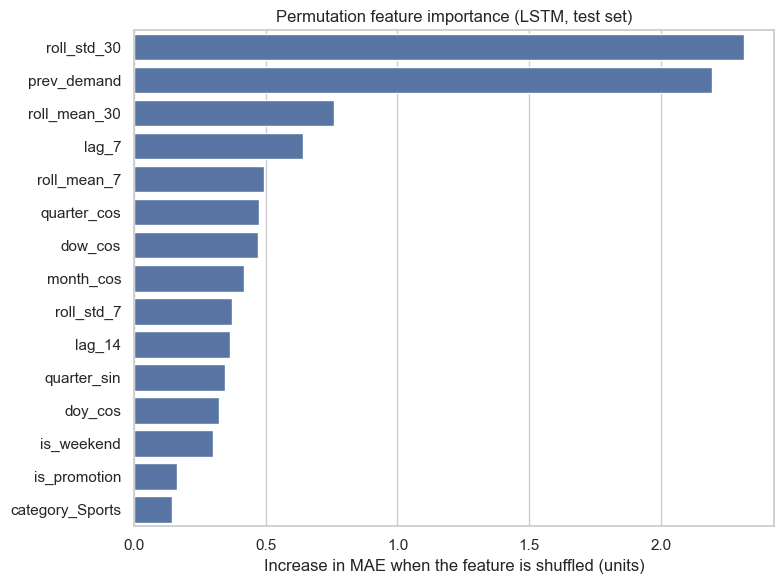

     feature  mae_increase
 roll_std_30      2.314996
 prev_demand      2.193509
roll_mean_30      0.758003
       lag_7      0.640259
 roll_mean_7      0.494238
 quarter_cos      0.471960
     dow_cos      0.470218
   month_cos      0.415291
  roll_std_7      0.372093
      lag_14      0.362328


In [29]:
from train import permutation_importance

importance = permutation_importance(lstm_model, test_seq, feature_columns, device)
importance.to_csv(OUTPUTS_DIR / 'feature_importance.csv', index=False)

top = importance.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top, x='mae_increase', y='feature', ax=ax, color='#4C72B0')
ax.set_title('Permutation feature importance (LSTM, test set)')
ax.set_xlabel('Increase in MAE when the feature is shuffled (units)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'feature_importance.png', dpi=130)
plt.show()

print(importance.head(10).to_string(index=False))

In [30]:
import time
from inference import (load_artifacts, prepare_features, forecast_for_product,
                       weekly_forecast, reorder_alerts)

start = time.time()
served_model, served_scaler, served_features = load_artifacts(str(MODELS_DIR))
serving_df = prepare_features(str(DATA_PATH))
forecast = forecast_for_product('P001', serving_df, served_model, served_scaler,
                                served_features, horizon_days=28)
elapsed = time.time() - start

print(weekly_forecast(forecast).to_string(index=False))
print(f'\nEnd-to-end inference (load + features + 28-day forecast): {elapsed:.2f}s')
print(f'Brief requires under 2 seconds: {"PASS" if elapsed < 2 else "see note"}')

      week  forecast_units
2024-01-01           404.9
2024-01-08           408.7
2024-01-15           416.6
2024-01-22           420.6

End-to-end inference (load + features + 28-day forecast): 1.04s
Brief requires under 2 seconds: PASS


In [31]:
latest = serving_df[serving_df.product_id == 'P001'].iloc[-1]
alerts = reorder_alerts(forecast, latest.stock_on_hand, latest.reorder_point)
print(f'P001 - stock on hand {latest.stock_on_hand:.0f}, '
      f'reorder point {latest.reorder_point:.0f}')
print(alerts.to_string(index=False))

P001 - stock on hand 0, reorder point 20
      week  forecast_units  projected_stock  reorder_needed
2024-01-01           404.9           -404.9            True
2024-01-08           408.7           -813.6            True
2024-01-15           416.6          -1230.2            True
2024-01-22           420.6          -1650.8            True


In [32]:
summary = pd.concat([
    daily_table.add_suffix(' (daily)'),
    weekly_table[['MAPE %', 'R2']].add_suffix(' (weekly)'),
], axis=1)
print(summary.round(3).to_string())

with open(OUTPUTS_DIR / 'metrics.json', 'w') as handle:
    json.dump({
        'LSTM': lstm_metrics, 'MLP': mlp_metrics, 'Naive baseline': naive_metrics,
        'LSTM_train': lstm_train_metrics, 'overfitting_check': overfit,
        'acceptance': acceptance.to_dict(orient='records'),
    }, handle, indent=2)
lstm_history.to_csv(OUTPUTS_DIR / 'lstm_history.csv', index=False)
mlp_history.to_csv(OUTPUTS_DIR / 'mlp_history.csv', index=False)
print('\nWrote metrics.json, lstm_history.csv, mlp_history.csv to outputs/')

                     MSE (daily)  RMSE (daily)  MAE (daily)  MAPE % (daily)  R2 (daily)  MAPE % (weekly)  R2 (weekly)
LSTM                      86.214         9.285        6.058          12.603       0.878            4.774        0.980
MLP                      112.344        10.599        7.001          14.163       0.840            4.917        0.971
Naive (roll_mean_7)      192.628        13.879        9.054          18.301       0.726            7.632        0.936

Wrote metrics.json, lstm_history.csv, mlp_history.csv to outputs/
